# ISLP Chapter 4 Lab
#### Author: Thomas Fitzgerald
This notebook contains my work for the lab accompanying Chapter 4 of [*An Introduction to Statistical Learning with Python* ("*ISLP*")](https://www.statlearning.com/). The fourth chapter of *ISLP* focuses on statistical models used for problems with a qualitative response (a.k.a. classification problems). This lab covers use of libraries introduced in the previous lab (**numpy**, **pandas**, **matplotlib**, **statsmodel**, and **ISLP**) as well as portions of the **sklearn** library. To begin, the libraries from the previous lab are imported:

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

Next, new libraries and sublibraries are imported:

In [2]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, 
    QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### The Stock Market Data
Next, the stock market data held in the **Smarket** data set is loaded:

In [3]:
Smarket = load_data("Smarket")
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


Recall, the **columns** attribute of the data frame can be used to inspect the variables included in the data.

In [4]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

The **corr()** method can be used to create a correlation matrix. By default, this method will include qualitative variables which, in the case of the Smarket data, causes an error. As such, to only include quantitative variables, the **numeric_only** keyword is set to true.

In [5]:
Smarket.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


Overall, there is little correlation between the different variables other than that between the year and value, which are positively correlated. That is valume tended to increase over time. This can be seen in plotting the **Volume** variable for each data point.

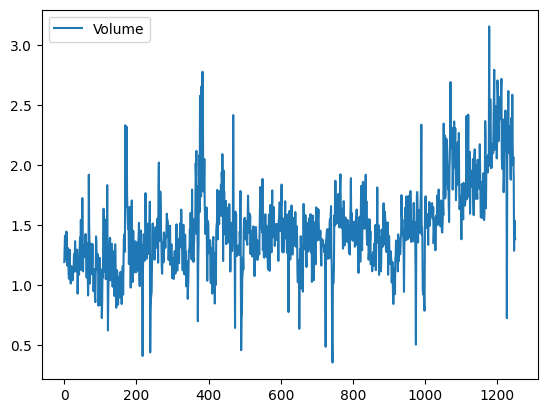

In [6]:
Smarket.plot(y="Volume");

### Logistic Regression
In this section, logistic regression is used to predict the direction of movement (**up** or **down**) on a given day. This prediction will rely on the **Lag 1** through **Lag 5** and **Volume** features. The **sm** model offers two methods to run a logistic regression:
* **sm.GLM()** that fits generalized linear models. This method requires a passed argument to specify the type of GLM to use. For example, to run a logistic regression, the command **sm.GLM(y, X, family=sm.families.Binomial())** is used.
* Alternatively, a logistic regression can be run directly using **sm.logit()**.

The former method is used below:

In [7]:
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Smarket)
y = Smarket.Direction == "Up"
glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


The relatively high p-values for the parameters of the logistic regression indicate that the null hypothesis cannot be solidly discounted a single one. The **params** attribute can be used to retrieve just the coefficients:

In [8]:
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

The p-values can be retrieved in a similar way using the **pvalues** attribute.

In [9]:
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

The **predict()** method can be used to get prediction based on a provided data set (or on the training data if no new data set is provided).

In [10]:
preds = results.predict()
preds[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

To convert these probabilities into predictions, they must be converted into class labels. In this case, a threshold of 0.50 is used with cases where $p>0.5$ assigned Up and all others assigned Down.

In [11]:
threshold = 0.5
labels = np.array(["Down"]*1250)
labels[preds > threshold] = "Up"
labels[:10]

array(['Up', 'Down', 'Down', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down'],
      dtype='<U4')

Confusion matrices can be used to display the performance of a statistical learning model. A confusion matrix displays the number of correctly and incorrectly classified observations by presenting the true class on one axis and the predicted class on the next. The **ISLP** library includes a **confusion_table()** function that takes as arguments the predicted classes and the true classes. 

In [12]:
confusion_table(labels, Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


The **np.mean()** function can be used to determine the fraction of correctly classified observations.

In [13]:
np.mean(labels == Smarket.Direction)

np.float64(0.5216)

So, it appears that this model performs slightly better than random guessing (it is right about 52% of the time). However, it is crucial to note that this is the *training* error rate. In practice, the generated model will be used on data not used in its training process. To get a better idea of *test* error rate, the training data can be split into a training set and a test set.

In [14]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_train.shape, Smarket_test.shape

((998, 9), (252, 9))

Above, the train vector is used to produce a boolean array corresponding to whether a row in the **Smaket** data frame have a year less than 2005. This boolean array can then be used to extract values from a dataframe based on whether the corresponding row is true or false. Further, it can be negated with the tilde ('~') sign. As can be seen, this results in a set of 998 training and 252 testing data points. Below, the same process is used for extracting rows from the predictor matrix and response vector.

In [15]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

To compare the predictions to the true results, the true directions for each set can be extracted and tested with the given threshold.

In [16]:
L_train, L_test = Smarket.Direction.loc[train], Smarket.Direction.loc[~train]
labels = np.array(['Down'] * 252)
threshold = 0.5
labels[probs > threshold] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


Taking the mean for accuracy yields:

In [17]:
np.mean(labels == L_test)

np.float64(0.4801587301587302)

This means that the error rate is roughly 52% on the test set (that is following the model's prediction is worse than would be expected from picking at random). This is not at all surprising given the high p-values associated with the predictors in the model. Still, could the model be improved by removing those predictors with the higher p-values (i.e. those least relevant for prediction)? It is well established that including unnecessary predictors can be deletorious to the predictive capabilities of a model. This is explored below by fitting a model with the two most relevant preditors, **Lag 1** and **Lag 2**.

In [18]:
model = MS(['Lag1', 'Lag2']).fit(Smarket)
X = model.transform(Smarket)
X_train, X_test = X[train], X[~train]
glm_model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_model.fit()
preds = results.predict(exog=X_test)
labels = np.array(['Down'] * 252)
labels[preds > threshold] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


Evaluating the test accuracy gives:

In [19]:
np.mean(L_test == labels)

np.float64(0.5595238095238095)

As can be seen the two-predictor model, results in a higher accuracy than the untrimmed model (56% vs. 48%). Though is is worth noting that a strategy of simply guessing the market will increase every day has a 56% accuracy rate as well. 

Now, suppose predictions are desired for the returns on two days given the values of **Lag1** and **Lag2** on those days. This can be achieved by creating a data frame with this information, converting it to a design matrix, and passing it to the fitted model.

In [20]:
new_data = pd.DataFrame({'Lag1': [1.2, 1.5], 'Lag2': [1.1, -0.8]})
new_X = model.transform(new_data)
results.predict(new_X)

0    0.479146
1    0.496094
dtype: float64

### Linear Discriminant Analysis
In this section, linear discriminant models are used for prediction on the **Smarket** data using the **LinearDiscriminantAnalysis()** (abbreviated to **LDA**). As done in the latter half of the preceding section, this model is split into a test and training set with the training set consisting of data points from before 2005.

In [21]:
lda = LDA(store_covariance=True)

Because LDA automatically adds an intercept, the intercept column should be removed from **X_train** and **X_test**.

In [22]:
X_train, X_test = [M.drop(columns=['intercept']) for M in [X_train, X_test]]
lda.fit(X_train, L_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [23]:
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In the **sklearn** library, the trailing underscore denotes a value estimated using the **fit()** method. The **classes_** method can be used to indicate which entry corresponds to which label.

In [24]:
lda.classes_, lda.priors_

(array(['Down', 'Up'], dtype='<U4'), array([0.49198397, 0.50801603]))

The discriminant vector can be displayed using the **scalings_** attribute.

In [25]:
lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

This discriminant vector denotes that LDA will utilize the equation $-0.64 * Lag1 - 0.51 * Lag2$ to assign the observation. Assigning it to **Up** if the result is large and **Down** if the result is small.

The **predict()** method can be used to obtain predictions from a set of data.

In [26]:
lda_preds = lda.predict(X_test)

And, a confusion table can, again, be used to make a comparison between the predicted and true responses.

In [27]:
confusion_table(lda_preds, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


There are several methods to get a predictions array that are, in effect, the same as using the **predict()** method. These approaches rely on the posterior probabilities obtained from the **predict_proba()** method.

In [28]:
lda_prob = lda.predict_proba(X_test)
alt_1 = np.where(lda_prob[:,1] >= 0.5, 'Up', 'Down')
alt_2 = [lda.classes_[i] for i in np.argmax(lda_prob, 1)]
np.all(alt_1 == lda_preds), np.all(alt_2 == lda_preds)

(np.True_, np.True_)

The first alternative has the added benefit that the threshold for assignment can be adjusted. 

The LDA model in this section utilized the **sklearn** library. Additional models from this library will be used in the following sections. All such libraries follow a common use pattern:
1. Instantiate the model.
2. Create a fitted the model using training data with the **fit()**.
3. Use the fitted model to make prediction with the **predict()** method.

This process allows for quick reuse of the chosen modelling method and provides uniformity across model types.

### Quadratic Discriminant Analysis
In this section, a quadratic discriminant analysis (QDA) model is implemented via sklearn's **QuadraticDiscriminantAnalysis()** function to make predictions on the **Smarket** data set. 

In [29]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [30]:
qda.means_, qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

The QDA classifier predicts one covariance per class and can be displayed with the **covariance_** attribute.

In [31]:
qda.covariance_

[array([[ 1.50662277, -0.03924806],
        [-0.03924806,  1.53559498]]),
 array([[ 1.51700576, -0.02787349],
        [-0.02787349,  1.49026815]])]

Analyzing the predictive performance of the QDA classifier, the following is observed.

In [32]:
qda_preds = qda.predict(X_test)
print("Accuracy: ", np.mean(L_test == qda_preds))
confusion_table(qda_preds, L_test)

Accuracy:  0.5992063492063492


Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


QDA performs considerably better than LDA with nearly 60% accuracy. This may suggest that the quadratic form assumed by QDA more accurately captures the true relationship between two-day lag and next-day market performance.

### Naive Bayes
In this section, **sklearn's** Gaussian naive Bayes model is used (in which each quantitative feature is modeled using a Gaussian distribution). However, **sklearn** also offers a kernel density method.

In [33]:
NB = GaussianNB()
NB.fit(X_train, L_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Classes and their priors are stored in the **classes_** and **class_prior_** attributes, respectively.

In [34]:
NB.classes_, NB.class_prior_

(array(['Down', 'Up'], dtype='<U4'), array([0.49198397, 0.50801603]))

The parameters of the features can be found in the **theta_** and **var_** attributes.

In [35]:
NB.theta_, NB.var_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([[1.50355429, 1.53246749],
        [1.51401364, 1.48732877]]))

In each parameter, the rows align with the classes (**Down** and **Up**) while the columns align with the features (**Lag1** and **Lag2**). Recall, the question mark can be used to query for information on an object (ex. **NB?** gives info on NB, which is a **GaussianNB()** return object). 

The means can ve easily verified with **mean()** on the filtered dataframe.

In [36]:
X_train[L_train == 'Down'].mean()

Lag1    0.042790
Lag2    0.033894
dtype: float64

The variance can be similarly calculated (passing in 0 as the delta degrees of freedom - **ddof**).

In [37]:
X_train[L_train == 'Down'].var(ddof=0)

Lag1    1.503554
Lag2    1.532467
dtype: float64

As an **sklearn** model, the **GaussianNB()** model makes predictions in the same manner as do the LDA and QDA models.

In [38]:
nb_preds = NB.predict(X_test)
print("Accuracy: ", np.mean(L_test == nb_preds))
confusion_table(nb_preds, L_test)

Accuracy:  0.5952380952380952


Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


The 59% accuracy of the naive Bayes approach is quite good (much better than LDA but slightly lagging QDA). 

### K-Nearest Neighbors
The **sklearn** model also provides a function for k-nearest neighbor classification (**KNeighborsClassifier()**). As would be expetced, this works very similarly to the previous **sklearn** functions used in this lab.

In [39]:
KNN_1 = KNeighborsClassifier(n_neighbors=1)
KNN_1.fit(X_train, L_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [40]:
knn_preds = KNN_1.predict(X_test)
print("Accuracy: ", np.mean(knn_preds == L_test))
confusion_table(knn_preds, L_test)

Accuracy:  0.5


Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


Using a single neighbor to predict the market direction appears to amount to random guessing. To see if using more neighbors for prediction improves results, a different neighbor count can be passed to the model.

In [41]:
KNN_3 = KNeighborsClassifier(n_neighbors=3)
KNN_3.fit(X_train, L_train)
knn_preds = KNN_3.predict(X_test)
print("Accuracy: ", np.mean(knn_preds == L_test))
confusion_table(knn_preds, L_test)

Accuracy:  0.5317460317460317


Truth,Down,Up
Predicted,,
Down,48,55
Up,63,86


Increasing the number of neighbors seems to only provide a marginal improvement in accuracy of the classifier. So, of the tested models, QDA is the clear choice for prediction using the prior two days' returns.

Though, in this case, the results of the k-nearest neighbor ("KNN") classifier were unimpressive, the approach can often provide highly accurate predictions. To demonstrate this fact, the textbook examines the **Caravan** dataset. This dataset consists of 85 predictors on 5,822 datapoints with a response variable indicating whether an individual purchased a caravan insurance policy (true in ~6% of cases). Begin by loading the data and examining the response:  

In [42]:
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

The features for this data set include all the columns except the response column, **Purchase**.

In [43]:
feats = Caravan.drop(columns=['Purchase'])

Given the nature of the KNN classifier, variable scale is incredibly influential on the classification results. While a 1,000 USD difference in salary is likely significant than a 50 year age difference, the KNN classifier will weight the 1,000 USD difference much more heavily. To remove the issue of variable scale from the KNN classification, it is important to standardize the features. This can be done with the **StandardScaler()** function from **sklearn**.

In [44]:
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)

The arguments are defined as follows:
- **with_mean**: Determines whether the mean should be subtracted.
- **with_std**: Scales output features to have a standard deviation of 1.
- **copy**: Determines whether calculations are done in place or moved to a different dataframe.

The scaler is then fit on the data of interest. This is done in two steps. First, the **fit()** method is called and the parameters for standardization are calculated. Next, the **transform()** method is used to create the standardized data.

In [45]:
scaler.fit(feats)
X_std = scaler.transform(feats)

Following standardization, the standardized data (**X_std**) should only contain features with a standard deviation of 1 and a mean of 0. To check, the data is converted to a **Pandas** data frame.

In [46]:
feats_std = pd.DataFrame(X_std, columns=feats.columns)
feats_std.std()

MOSTYPE     1.000086
MAANTHUI    1.000086
MGEMOMV     1.000086
MGEMLEEF    1.000086
MOSHOOFD    1.000086
              ...   
AZEILPL     1.000086
APLEZIER    1.000086
AFIETS      1.000086
AINBOED     1.000086
ABYSTAND    1.000086
Length: 85, dtype: float64

With the data standardized, the analysis can move forward. To begin, the data is split into a test set of 1,000 observations and a training set with the remaining observations. The **test_train_split()** method from the **sklearn** library provides functionality for this process.

In [47]:
split = train_test_split(feats_std, Purchase, test_size=1000, random_state=0)
(X_train, X_test, y_train, y_test) = split 

With the standardized data set, the KNN classifier can be tested on the results. First, a KNN classifier with a single neighbor is computed.

In [48]:
KNN_1 = KNeighborsClassifier(n_neighbors=1)
KNN_1.fit(X_train, y_train)
preds = KNN_1.predict(X_test)
np.mean(preds == y_test), np.mean(y_test == 'No')

(np.float64(0.889), np.float64(0.933))

Using a single neighbor, the accuracy of the classifier is roughly 89%, which may appear quite good. However, simply guessing that no purchase was made in all cases results in an accuracy of just over 93%, so there is clearly room for improvement. Though this does not mean the classification is without application. Suppose the company selling insurance is interested in only marketing their policies to individuals that are likely to buy insurance. In such a case, the accuracy in predicting true buyers is more important.

In [49]:
confusion_table(preds, y_test)

Truth,No,Yes
Predicted,,
No,880,58
Yes,53,9


In [50]:
print(f"Right {(9 * 100 / 62):.2f}% of the time when predicting a buyer!")

Right 14.52% of the time when predicting a buyer!


As can be seen, if the model were used to focus only on likely buyers, the accuracy rate is more than twice the performace of random guessing (though most buyers are left out as a result).

###### Tuning Parameters
The number of neighbors used in a KNN classifier is known as a *tuning parameter* or a *hyperparameter*. It is not known at the outset of analysis which value for the number of neighbors produces the most accurate model. Therefore, it is advisable to test out varying numbers of neighbors. This can be done using a for loop that varies neighbor count.

In [51]:
for k in range(1, 6):
    KNN = KNeighborsClassifier(n_neighbors=k)
    KNN.fit(X_train, y_train)
    preds = KNN.predict(X_test)
    C = confusion_table(preds, y_test)
    templ = ('K={0:d}: # predicted to buy: {1:>2},' +
            ' # who did buy {2:d}, accuracy {3:.1%} ')
    pred = C.loc['Yes'].sum()
    did_rent = C.loc['Yes','Yes']
    ratio = did_rent / pred
    print(templ.format(k, pred, did_rent, ratio))

K=1: # predicted to buy: 62, # who did buy 9, accuracy 14.5% 
K=2: # predicted to buy:  6, # who did buy 1, accuracy 16.7% 
K=3: # predicted to buy: 20, # who did buy 3, accuracy 15.0% 
K=4: # predicted to buy:  4, # who did buy 0, accuracy 0.0% 
K=5: # predicted to buy:  7, # who did buy 1, accuracy 14.3% 


The results are slightly variable in terms of accuracy (excluding the results for $k = 4$ which are very different from the rest). 

###### Comparison to Logistic Regression
As a comparison to the results of the KNN classifier, a logistic regression classifier can be used with the **sklearn** library. By default, this method is similar to a *ridge regression* (discussed in Chapter 6 of *ISLP*). However, setting the C argument to the **LogisticRegression()** function to a sufficiently large value will set the model closer to an unmodified logistic regression. 

In [52]:
logit = LogisticRegression(C=1e10, solver='liblinear')
logit.fit(X_train, y_train)
preds = logit.predict(X_test)
print(f"Accuracy: {np.mean(preds == y_test):.2f}%")
confusion_table(preds, y_test)

Accuracy: 0.93%


Truth,No,Yes
Predicted,,
No,931,67
Yes,2,0


Of course, with a logistic regression, a different threshold for classification can be used. For example, should the company only require a 25% likelihood to pursue a lead, that likelihood could be used as a threshold.

In [53]:
probs = logit.predict_proba(X_test)
labels = np.where(probs[:,1] > 0.25, 'Yes', 'No')
print(f"Accuracy: {np.mean(labels == y_test):.2f}%")
confusion_table(labels, y_test)

Accuracy: 0.92%


Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


Though this approach results in lower overall probability, it results in a true policy purchase rate of roughly 31% versus the 0% rate of the unmodified classifier.

### Linear and Poisson Regression on the Bikeshare Data
In this section, a data set containing detailed information on hourly bike rental usership in Washington DC is used to demostrate linear and Poisson regression models. First, the dataset is loaded and broad characteristics of the data set are inspected.

In [54]:
Bike = load_data('Bikeshare')
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

###### Linear Regression
To begin, a linear regression model is fit on the **Bikeshare** data.

In [55]:
X = MS(['mnth', 'hr', 'workingday', 'temp', 'weathersit']).fit_transform(Bike)
y = Bike['bikers']
M_lr = sm.OLS(y, X).fit()
summarize(M_lr)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In total, there are 40 rows in the summary. This is in large part due to the discrete nature of the **mnth** and **hr** parameters that are broken out into individual categories. It is interesting to note that the **mnth[Jan]** and **hr[0]** categories are not included. This is a result of their use as a baseline against which other options in their category are measured. For example, the coefficient of 6.8 in February indicates that on average there are about 7 more riders in February than in January.

A different encoding can be used to get the same results through use of the **contrast()** function. Using such an encoding sets the value of the final option is the baseline. The baseline's value is unreported and is equal to the negative of the sum of all other coefficients (as a result, they will sum to zero). Each coefficient can then be interpreted as the difference of that category from mean level.

In [58]:
hr_encode = contrast('hr', 'sum')
mnth_encode = contrast('mnth', 'sum')

X2 = MS([mnth_encode, hr_encode, 'workingday', 'temp', 'weathersit']).fit_transform(Bike)
M2_lr = sm.OLS(y, X2).fit()
summarize(M2_lr)

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


Note, the encoding does not carry much weight other than changing how the model's coefficients are interpreted. As can be seen below, changing the coefficients has no result on the predicted values.

In [67]:
np.sum((M_lr.fittedvalues - M2_lr.fittedvalues)**2)

np.float64(1.481267584034537e-20)

In [64]:
np.allclose(M_lr.fittedvalues, M2_lr.fittedvalues)

True

For graphing purposes, the coefficients of all months are needed. The first 11 coefficients are directly included in the summary, but the coefficient for **Dec** must be computed as the negative sum of all other coefficients.

In [69]:
S = summarize(M2_lr)
mnth_coefs = S[S.index.str.contains('mnth')]['coef']
data_type = Bike['mnth'].dtype.categories
mnth_coefs = pd.concat([
    mnth_coefs,
    pd.Series([-mnth_coefs.sum()], index = ['mnth[Dec]'])
])
mnth_coefs

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
mnth[Dec]       0.3705
dtype: float64

To create a cleaner graph, the plot is charted using only the first letter of each month on the axis.

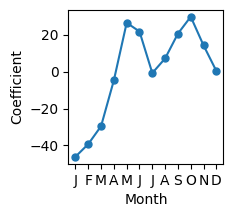

In [82]:
fig_mnth, ax_mnth = subplots(figsize=(2,2))
x_mnth = np.arange(mnth_coefs.shape[0])
ax_mnth.plot(x_mnth, mnth_coefs, marker='o', ms=5)
ax_mnth.set_xticks(x_mnth)
ax_mnth.set_xticklabels([l[5] for l in mnth_coefs.index], fontsize=10)
ax_mnth.set_xlabel('Month', fontsize=10)
ax_mnth.set_ylabel('Coefficient', fontsize=10)
ax_mnth;

A similar process can be followed to plot the hourly coefficients.

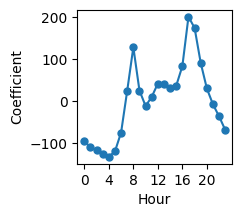

In [88]:
hr_coefs = S[S.index.str.contains('hr')]['coef']
hr_coefs = hr_coefs.reindex(['hr[{0}]'.format(h) for h in range(23)])
hr_coefs = pd.concat([
    hr_coefs,
    pd.Series([-hr_coefs.sum()], index=['hr[23]'])
])
fig_hr, ax_hr = subplots(figsize=(2,2))
x_hr = np.arange(hr_coefs.shape[0])
ax_hr.plot(x_hr, hr_coefs, marker='o', ms='5')
ax_hr.set_xticks(x_hr[::4])
ax_hr.set_xticklabels(range(24)[::4], fontsize=10)
ax_hr.set_xlabel('Hour', fontsize=10)
ax_hr.set_ylabel('Coefficient', fontsize=10)
ax_hr;

###### Poisson Regression
The process for employing a Poisson model is quite similar to that for a linear regression model except that the **sm.GLM()** function is used with the Poisson family selected.

In [89]:
M_pois = sm.GLM(y, X2, family=sm.families.Poisson()).fit()

The coefficients of the Poisson model can then be charted as was done with the linear regression model. First, prepare the data for plotting.

In [94]:
SP = summarize(M_pois)
# First, for months
mnth_coefs = SP[SP.index.str.contains('mnth')]['coef']
mnth_coefs = pd.concat([
    mnth_coefs,
    pd.Series([-mnth_coefs.sum()], index=['mnth[Dec]'])
])
# Next, for hours
hr_coefs = SP[SP.index.str.contains('hr')]['coef']
hr_coefs = pd.concat([
    hr_coefs,
    pd.Series([-hr_coefs.sum()], index=['hr[23]'])
])

Now, with the data properly formatted, the plots can be set up.

Text(0, 0.5, 'Coefficient')

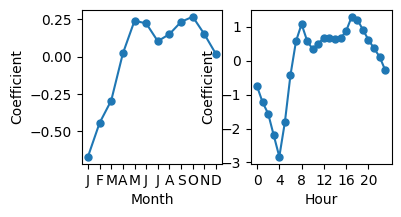

In [97]:
fig, (ax_mnth, ax_hr) = subplots(1, 2, figsize=(4, 2))
# plot charts
ax_mnth.plot(x_mnth, mnth_coefs, marker='o', ms=5)
ax_hr.plot(x_hr, hr_coefs, marker='o', ms=5)
# add labeling
ax_mnth.set_xticks(x_mnth)
ax_mnth.set_xticklabels([l[5] for l in mnth_coefs.index], fontsize=10)
ax_mnth.set_xlabel('Month', fontsize=10)
ax_mnth.set_ylabel('Coefficient', fontsize=10)
ax_hr.set_xticks(x_hr[::4])
ax_hr.set_xticklabels(range(24)[::4])
ax_hr.set_xlabel('Hour', fontsize=10)
ax_hr.set_ylabel('Coefficient', fontsize=10)

The fitted values of the linear regression and Poisson regression can be plotted against each other using the **fittedvalues** attribute of the models.

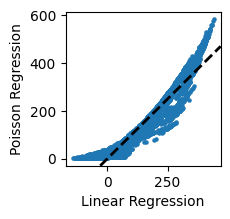

In [103]:
fig, ax = subplots(figsize=(2, 2))
ax.scatter(M2_lr.fittedvalues, M_pois.fittedvalues, s=5)
ax.set_xlabel('Linear Regression', fontsize=10)
ax.set_ylabel('Poisson Regression', fontsize=10)
ax.axline([0,0], c='black', linewidth=2, linestyle='--', slope=1)

The curved shape of the relationship (contrasted against a one-to-one relationship) demonstrates that Poisson regression coefficients tend to be larger than those for linear regression for very low and very high levels of ridership.